#### Output Characteristics

This output sweep evaluates drain current ($I_D$) versus drain voltage ($V_{DS}$) at 2 gate biases, highlighting the impact of self-heating on device performance.
   * Linear & Saturation Region: At low $V_{DS}$, the 2DEG exhibits linear ohmic conduction, with $V_{GS}$ directly modulating carrier density. As $V_{DS}$ scales, strong lateral electric fields cause velocity saturation and channel pinch-off, clamping $I_D$ into saturation.
   * Negative Differential Resistance (NDR): At moderate-to-high drain biases, massive power dissipation ($P = V \cdot I$) induces immense self-heating. The hotter lattice triggers intense polar optical phonon scattering, which degrades electron mobility and causes $I_D$ to drop even as voltage increases.
   * Electro-Thermal Collapse: At extreme $V_{DS}$, the combination of a concentrated electric field and a severe thermal hotspot drastically degrades carrier mobility , resulting in a steep current collapse.


 RUNNING (Vg = 0.0V, Vds = 10.0V)
Iter   0 | ΔV: 10695.75mV | Max Temp: 300.0K | I_D: 29.0 mA/mm | Max n_s: 1.30e+12 cm^-2
Iter  10 | ΔV: 6301.15mV | Max Temp: 301.7K | I_D: 533.6 mA/mm | Max n_s: 3.41e+13 cm^-2
Iter  20 | ΔV: 3768.43mV | Max Temp: 303.7K | I_D: 793.5 mA/mm | Max n_s: 6.60e+13 cm^-2
Iter  30 | ΔV: 2253.77mV | Max Temp: 305.7K | I_D: 1486.2 mA/mm | Max n_s: 9.24e+13 cm^-2
Iter  40 | ΔV: 1347.26mV | Max Temp: 307.7K | I_D: 1740.9 mA/mm | Max n_s: 1.13e+14 cm^-2
Iter  50 | ΔV: 804.85mV | Max Temp: 309.7K | I_D: 1251.5 mA/mm | Max n_s: 1.29e+14 cm^-2
Iter  60 | ΔV: 477.77mV | Max Temp: 311.7K | I_D: 1124.9 mA/mm | Max n_s: 1.42e+14 cm^-2
Iter  70 | ΔV: 279.64mV | Max Temp: 313.7K | I_D: 1175.5 mA/mm | Max n_s: 1.50e+14 cm^-2
Iter  80 | ΔV: 167.43mV | Max Temp: 315.7K | I_D: 1319.0 mA/mm | Max n_s: 1.56e+14 cm^-2
Iter  90 | ΔV: 154.05mV | Max Temp: 317.7K | I_D: 1414.4 mA/mm | Max n_s: 1.72e+14 cm^-2
Iter 100 | ΔV: 181.76mV | Max Temp: 319.7K | I_D: 1427.8 mA/mm | Max n_s:

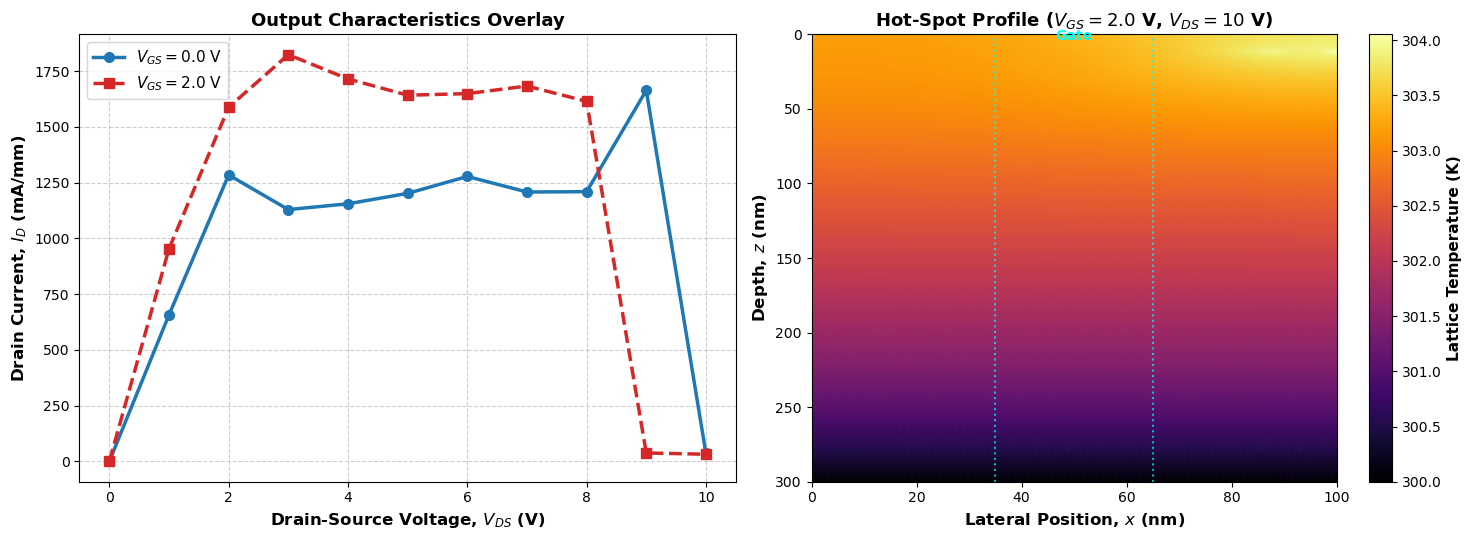

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sparse
import scipy.sparse.linalg as spla
import scipy.linalg as la
import scipy.constants as const


# 1. PHYSICAL PARAMETERS & MATERIAL PROPERTIES
q = const.e
hbar = const.hbar
eps0 = const.epsilon_0
kB = const.k
T_amb = 300.0        # Ambient temperature (K)
m0 = const.m_e

# HEMT Operating Conditions
x_al = 0.22          # 22% Al Content
V_schottky = 1.2     # Schottky barrier height (V)
V_surface_pin = -1.2 # Fermi pinning level in access regions (V)
Vg_list = [0.0, 2.0] # Gate voltages to simulate (V)

# Transport Physics Parameters
mu_0 = 0.12          # Calibrated 2DEG low-field mobility at 300K (m^2/Vs)
v_sat_300K = 1.1e5   # Effective saturation velocity in GaN at 300K (m/s)
beta_CT = 2.0        # Caughey-Thomas empirical beta

# Thermal Parameters
kappa_GaN = 130.0    # Thermal conductivity of GaN (W/m-K)
kappa_AlGaN = 20.0   # Thermal conductivity of AlGaN (W/m-K)
gamma_mu = 2.0       # Temperature exponent for mobility degradation
gamma_vsat = 1.5     # Temperature exponent for vsat degradation

# Deep Buffer Trap Parameters
E_dA = 2.5 * q       
g_A = 4.0            

# Material parameters
m_GaN = 0.20 * m0
m_AlGaN = (0.32 * x_al + 0.20 * (1.0 - x_al)) * m0
eps_GaN = 8.9 * eps0
eps_AlGaN = (8.5 * x_al + 8.9 * (1.0 - x_al)) * eps0
dE_c = 0.7 * (3.07 * x_al + 0.7 * x_al * (1.0 - x_al)) * q  

# Spontaneous & Piezoelectric Polarization Calculation
P_SP_GaN = -0.034
P_SP_AlGaN = -0.090 * x_al - 0.034 * (1.0 - x_al) + 0.021 * x_al * (1.0 - x_al)
a_GaN, a_AlN = 0.3189e-9, 0.3112e-9
a_AlGaN = a_AlN * x_al + a_GaN * (1.0 - x_al)
strain_inplane = (a_GaN - a_AlGaN) / a_AlGaN
e31 = -0.11 * x_al - 0.49 * (1.0 - x_al)
e33 = 0.73 * x_al + 0.97 * (1.0 - x_al)
C13 = (103 * x_al + 106 * (1.0 - x_al)) * 1e9
C33 = (405 * x_al + 398 * (1.0 - x_al)) * 1e9
P_PE_AlGaN = 2 * strain_inplane * (e31 - e33 * (C13 / C33))
sigma_pol = (P_SP_GaN - (P_SP_AlGaN + P_PE_AlGaN)) / q  


# 2. DEVICE TOPOLOGY & MESH GENERATION
L_s, L_sg, L_g, L_gd, L_d = 15e-9, 20e-9, 30e-9, 20e-9, 15e-9
Lx = L_s + L_sg + L_g + L_gd + L_d
t_barrier, t_buffer = 12.0e-9, 288.0e-9 
Lz = t_barrier + t_buffer

z_top = np.linspace(0, 9e-9, 15, endpoint=False)
z_2deg = np.linspace(9e-9, 18e-9, 65, endpoint=False) 
z_buf = np.geomspace(18e-9, Lz, 40)
z = np.unique(np.sort(np.concatenate([z_top, z_2deg, z_buf])))
Nz = len(z)

x_gate1 = L_s + L_sg
x_gate2 = x_gate1 + L_g
x_s = np.linspace(0, L_s, 10, endpoint=False)
x_sg = np.linspace(L_s, x_gate1, 15, endpoint=False)
x_g = np.linspace(x_gate1, x_gate2, 25, endpoint=False)
x_gd = np.linspace(x_gate2, Lx - L_d, 15, endpoint=False)
x_d = np.linspace(Lx - L_d, Lx, 15)
x = np.unique(np.sort(np.concatenate([x_s, x_sg, x_g, x_gd, x_d])))
Nx = len(x)

X, Z = np.meshgrid(x, z)
idx_int = np.argmin(np.abs(z - t_barrier))

dx_R = np.diff(x); dx_L = np.roll(dx_R, 1)                  
dx_avg = 0.5 * (np.append(dx_R, dx_R[-1]) + np.insert(dx_L, 0, dx_L[0]))
dz_R = np.diff(z); dz_L = np.roll(dz_R, 1)                  
dz_avg = 0.5 * (np.append(dz_R, dz_R[-1]) + np.insert(dz_L, 0, dz_L[0]))

m_eff = np.where(Z <= t_barrier, m_AlGaN, m_GaN)
eps_r = np.where(Z <= t_barrier, eps_AlGaN, eps_GaN)
kappa_grid = np.where(Z <= t_barrier, kappa_AlGaN, kappa_GaN)
V_band = np.where(Z <= t_barrier, dE_c, 0.0)

source_mask = (X <= L_s) & (Z == 0)
gate_mask = (X >= x_gate1) & (X <= x_gate2) & (Z == 0)
drain_mask = (X >= Lx - L_d) & (Z == 0)


# 3. DOPING
rho_fixed = np.zeros((Nz, Nx))
rho_fixed[idx_int+1:, :] += q * 1e22 
rho_fixed[idx_int, :] += (q * sigma_pol) / dz_avg[idx_int]

N_D_contacts = 2e25 
contact_depth = t_barrier + 2e-9
rho_fixed[(X <= L_s) & (Z <= contact_depth)] += q * N_D_contacts
rho_fixed[(X >= Lx - L_d) & (Z <= contact_depth)] += q * N_D_contacts

t_buffer_doped_start = t_barrier + 20e-9
idx_buffer_doped = np.max(np.where(z <= t_buffer_doped_start)[0])
N_acceptor = 5e22 

buf_trap_mask = np.zeros((Nz, Nx), dtype=bool)
buf_trap_mask[idx_buffer_doped:, :] = True

N_C_GaN = 2.0 * ((m_GaN * kB * T_amb) / (2.0 * np.pi * hbar**2))**1.5 
n_ratio = N_D_contacts / N_C_GaN
V_bi = (kB * T_amb / q) * (np.log(n_ratio) + n_ratio / np.sqrt(8))


# 4. 2D MATRICES (POISSON & THERMAL)
N_tot = Nx * Nz
A_poisson_base = sparse.lil_matrix((N_tot, N_tot))
A_therm_base = sparse.lil_matrix((N_tot, N_tot))

def get_k(i, j): return j * Nx + i

for j in range(Nz):
    for i in range(Nx):
        k = get_k(i, j)
        
        # Poisson Stencil Setup
        if gate_mask[j, i] or source_mask[j, i] or drain_mask[j, i] or j == 0:
            A_poisson_base[k, k] = 1.0
        elif j == Nz - 1: 
            A_poisson_base[k, k] = 1.0; A_poisson_base[k, get_k(i, j-1)] = -1.0
        elif i == 0:      
            A_poisson_base[k, k] = 1.0; A_poisson_base[k, get_k(i+1, j)] = -1.0
        elif i == Nx - 1: 
            A_poisson_base[k, k] = 1.0; A_poisson_base[k, get_k(i-1, j)] = -1.0
        else:
            dx_r_i, dx_l_i, dx_a_i = dx_R[i], dx_R[i-1], dx_avg[i]
            dz_r_j, dz_l_j, dz_a_j = dz_R[j], dz_R[j-1], dz_avg[j]
            
            exP = 0.5 * (eps_r[j, i] + eps_r[j, i+1]); exM = 0.5 * (eps_r[j, i] + eps_r[j, i-1])
            ezP = 0.5 * (eps_r[j, i] + eps_r[j+1, i]); ezM = 0.5 * (eps_r[j, i] + eps_r[j-1, i])
            c_iP, c_iM = exP / (dx_a_i * dx_r_i), exM / (dx_a_i * dx_l_i)
            c_jP, c_jM = ezP / (dz_a_j * dz_r_j), ezM / (dz_a_j * dz_l_j)
            A_poisson_base[k, get_k(i+1, j)] = c_iP; A_poisson_base[k, get_k(i-1, j)] = c_iM
            A_poisson_base[k, get_k(i, j+1)] = c_jP; A_poisson_base[k, get_k(i, j-1)] = c_jM
            A_poisson_base[k, k] = -(c_iP + c_iM + c_jP + c_jM)

        # Thermal Stencil Setup
        if j == Nz - 1:   
            A_therm_base[k, k] = 1.0
        elif i == 0:      
            A_therm_base[k, k] = 1.0; A_therm_base[k, get_k(i+1, j)] = -1.0
        elif i == Nx - 1: 
            A_therm_base[k, k] = 1.0; A_therm_base[k, get_k(i-1, j)] = -1.0
        elif j == 0:      
            A_therm_base[k, k] = 1.0; A_therm_base[k, get_k(i, j+1)] = -1.0
        else:
            dx_r_i, dx_l_i, dx_a_i = dx_R[i], dx_R[i-1], dx_avg[i]
            dz_r_j, dz_l_j, dz_a_j = dz_R[j], dz_R[j-1], dz_avg[j]
            
            kxP = 0.5 * (kappa_grid[j, i] + kappa_grid[j, i+1]); kxM = 0.5 * (kappa_grid[j, i] + kappa_grid[j, i-1])
            kzP = 0.5 * (kappa_grid[j, i] + kappa_grid[j+1, i]); kzM = 0.5 * (kappa_grid[j, i] + kappa_grid[j-1, i])
            tc_iP, tc_iM = kxP / (dx_a_i * dx_r_i), kxM / (dx_a_i * dx_l_i)
            tc_jP, tc_jM = kzP / (dz_a_j * dz_r_j), kzM / (dz_a_j * dz_l_j)
            A_therm_base[k, get_k(i+1, j)] = tc_iP; A_therm_base[k, get_k(i-1, j)] = tc_iM
            A_therm_base[k, get_k(i, j+1)] = tc_jP; A_therm_base[k, get_k(i, j-1)] = tc_jM
            A_therm_base[k, k] = -(tc_iP + tc_iM + tc_jP + tc_jM)

A_csr = A_poisson_base.tocsr()
A_therm_csr = A_therm_base.tocsr()


# 5. ELECTRO-THERMAL GUMMEL LOOP (Vds SWEEP)
max_iter_limit = 3000
min_iters = 250
n_subbands = 3

window_size = 5
convergence_tol = 1e-4  # mA/mm threshold
max_diverge_steps = 3    
trend_window_size = max_diverge_steps * 2  

# Mixing parameters
alpha_p, alpha_n, alpha_EF, alpha_T = 0.05, 0.025, 0.025, 0.02

# Vds Sweep Setup: 10V to 0V with 1V spacing
Vds_sweep = np.arange(10.0, -0.1, -1.0)

# Store sweep results
results = {Vg: {'Vds': [], 'Id': [], 'T_2d_max': None} for Vg in Vg_list}

for Vg_current in Vg_list:
    for Vds_current in Vds_sweep:
        print("\n" + "="*60)
        print(f" RUNNING (Vg = {Vg_current:.1f}V, Vds = {Vds_current:.1f}V)")
        print("="*60)

        Id_history = []
        moving_avg_prev = None
        diverge_count = 0
        best_stable_Id = 0.0
        recent_trends = []  
        
        T_max_prev = T_amb
        I_d_prev = 0.0

        phi = np.zeros((Nz, Nx))
        n_2d = np.zeros((Nz, Nx))
        T_2d = np.full((Nz, Nx), T_amb)
        T_channel = np.full(Nx, T_amb)
        V_tot = np.copy(V_band)

        V_ef_lat = np.linspace(0, Vds_current, Nx)
        E_F_lat = -q * V_ef_lat

        idx_qbox = np.argmin(np.abs(z - (t_barrier + 95.0e-9)))

        dirichlet_mask = gate_mask | source_mask | drain_mask
        surface_pin_mask = (Z == 0) & ~dirichlet_mask
        outer_bc_mask = ((Z == Lz) | (X == 0) | (X == Lx)) & (Z > 0)
        interior_mask = ~(dirichlet_mask | surface_pin_mask | outer_bc_mask)

        N_DOS_3D_equiv = np.broadcast_to((m_GaN * kB * T_amb) / (np.pi * hbar**2 * dz_avg[:, np.newaxis]), (Nz, Nx))
        b_base_2d = np.zeros((Nz, Nx))
        b_base_2d[gate_mask] = Vg_current - (V_schottky - dE_c / q)
        b_base_2d[source_mask] = V_bi
        b_base_2d[drain_mask] = Vds_current + V_bi
        b_base_2d[surface_pin_mask] = V_surface_pin

        Ex_abs = np.zeros(Nx)
        mu_field = np.zeros(Nx)
        I_d_channel = np.zeros(Nx)
        I_d_avg = 0.0

        for iteration in range(max_iter_limit):
            # --- A. Poisson Block ---
            b_2d = np.copy(b_base_2d)
            E_C = V_band - q * phi; E_A = E_C - E_dA
            E_Fn = E_F_lat[np.newaxis, :] 
            
            exp_term_A = g_A * np.exp(np.clip((E_A - E_Fn) / (kB * T_amb), -700.0, 700.0))
            f_A = 1.0 / (1.0 + exp_term_A) 
            
            rho_trap = np.zeros((Nz, Nx))
            rho_trap[buf_trap_mask] = -q * N_acceptor * f_A[buf_trap_mask]
            
            rho_total = rho_fixed + rho_trap
            b_2d[interior_mask] = -(rho_total[interior_mask] - q * n_2d[interior_mask])
            
            term_n = np.exp(-np.minimum(n_2d[interior_mask] / N_DOS_3D_equiv[interior_mask], 700.0))
            D_electrons = (q**2 * N_DOS_3D_equiv[interior_mask] / (kB * T_amb)) * (1.0 - term_n)
            
            exp_A_sub = exp_term_A[buf_trap_mask]
            df_dE = np.where(
                exp_A_sub > 1e15, 
                0.0, 
                exp_A_sub / (1.0 + exp_A_sub)**2
            )
            
            D_traps = np.zeros((Nz, Nx))
            D_traps[buf_trap_mask] = (q**2 * N_acceptor / (kB * T_amb)) * df_dE
            
            D_gummel_2d = np.zeros((Nz, Nx))
            D_gummel_2d[interior_mask] = D_electrons + D_traps[interior_mask]
            
            D_gummel_flat = D_gummel_2d.flatten()
            A_gummel_dynamic = A_csr - sparse.diags(D_gummel_flat, format='csr')
            b_gummel_dynamic = b_2d.flatten() - D_gummel_flat * phi.flatten()
            
            phi_new = spla.spsolve(A_gummel_dynamic, b_gummel_dynamic).reshape((Nz, Nx))
            err_phi = np.max(np.abs(phi_new - phi))
            
            phi = alpha_p * phi_new + (1 - alpha_p) * phi
            V_tot = np.clip(V_band - q * phi, -15 * q, 5 * q) 
            
            # B. Schrödinger Block
            n_new = np.zeros((Nz, Nx))
            V_xc_raw = -(q**2 / (4.0 * np.pi * eps_r)) * (3.0 * np.maximum(n_2d, 1e12) / np.pi)**(1.0 / 3.0)
            V_xc = np.clip(V_xc_raw, -0.05 * q, 0.0)
            V_quantum_2d = V_tot + V_xc
            N_int = idx_qbox - 2
            
            for i in range(Nx):
                V_quantum = V_quantum_2d[:idx_qbox, i]; m_col = m_eff[:idx_qbox, i]
                d_int = np.zeros(N_int); e_int = np.zeros(N_int - 1)
                
                for k in range(N_int):
                    j = k + 1
                    dz_r, dz_l, dz_a = dz_R[j], dz_R[j-1], dz_avg[j]
                    inv_mp, inv_mm = 0.5*(1.0/m_col[j] + 1.0/m_col[j+1]), 0.5*(1.0/m_col[j] + 1.0/m_col[j-1])
                    d_int[k] = V_quantum[j] + (hbar**2 / (2.0 * dz_a)) * (inv_mp / dz_r + inv_mm / dz_l)
                    if k < N_int - 1:
                        e_int[k] = -(hbar**2 / 2.0) * (inv_mp / dz_r) / np.sqrt(dz_a * dz_avg[j+1])
                
                evals, evecs_int = la.eigh_tridiagonal(d_int, e_int, select='i', select_range=(0, n_subbands-1))
                evecs_full = np.zeros((idx_qbox, n_subbands))
                evecs_full[1:-1, :] = evecs_int
                
                for m in range(n_subbands):
                    m_eff_subband = m_GaN * (1.0 + (0.6/q) * np.maximum(evals[m] - V_quantum[idx_int], 0.0))
                    n_s = ((m_eff_subband * kB * T_amb) / (np.pi * hbar**2)) * np.logaddexp(0, (E_F_lat[i] - evals[m]) / (kB * T_amb))
                    u_sq = evecs_full[:, m]**2
                    psi_sq = (u_sq / dz_avg[:idx_qbox]) / np.sum(u_sq)
                    psi_sq_full = np.zeros(Nz); psi_sq_full[:idx_qbox] = psi_sq
                    n_new[:, i] += n_s * psi_sq_full 
                    
            n_2d = alpha_n * n_new + (1 - alpha_n) * n_2d  
            
            # C. Electro-Thermal Transport Block
            n_s_eff = np.maximum(np.sum(n_2d * dz_avg[:, np.newaxis], axis=0), 1e10)
            
            mu_T_scale = (T_amb / T_channel)**gamma_mu
            v_sat_T_scale = (T_amb / T_channel)**gamma_vsat
            
            mu_pop, mu_dis, mu_irs, n_ref = 0.15, 0.20, 0.10, 1.0e17        
            inv_mu_dis = 1.0 / (mu_dis * (n_s_eff / n_ref)**0.5)
            inv_mu_pop = 1.0 / mu_pop
            inv_mu_irs = 1.0 / (mu_irs * (n_ref / n_s_eff)**2.5)
            
            mu_0_lat = (1.0 / (inv_mu_dis + inv_mu_pop + inv_mu_irs)) * mu_T_scale
            v_sat_lat = v_sat_300K * v_sat_T_scale
            
            Ex = np.zeros(Nx)
            Ex[1:-1] = -(phi[idx_int, 2:] - phi[idx_int, :-2]) / (x[2:] - x[:-2])
            Ex[0] = -(phi[idx_int, 1] - phi[idx_int, 0]) / dx_R[0]
            Ex[-1] = -(phi[idx_int, -1] - phi[idx_int, -2]) / dx_R[-1]
            Ex_abs = np.maximum(np.abs(Ex), 1e2)  
            
            den_mobility = (1.0 + (mu_0_lat * Ex_abs / v_sat_lat)**beta_CT)**(1.0 / beta_CT)
            mu_field = mu_0_lat / den_mobility
            G_eff = n_s_eff * mu_field
            
            G_mid = 2.0 * (G_eff[:-1] * G_eff[1:]) / (G_eff[:-1] + G_eff[1:] + 1e-30)
            
            R_c = 1.2e-3  
            
            I_est = np.mean(I_d_channel[1:-1]) if iteration > 0 else 1000.0 
            V_s_eff = (I_est * 1e-3) * R_c
            V_d_eff = Vds_current - (I_est * 1e-3) * R_c
            
            A_1D = sparse.lil_matrix((Nx, Nx)); b_1D = np.zeros(Nx)
            for i in range(Nx):
                if i == 0: 
                    A_1D[i, i] = 1.0; b_1D[i] = V_s_eff  
                elif i == Nx - 1: 
                    A_1D[i, i] = 1.0; b_1D[i] = V_d_eff  
                else:
                    lc, rc = G_mid[i - 1] / dx_R[i - 1], G_mid[i] / dx_R[i]
                    A_1D[i, i - 1] = lc; A_1D[i, i + 1] = rc; A_1D[i, i] = -(lc + rc)
                    
            V_ef_new = spla.spsolve(A_1D.tocsr(), b_1D)
            V_ef_lat = alpha_EF * V_ef_new + (1 - alpha_EF) * V_ef_lat
            E_F_lat = -q * V_ef_lat
            
            dVef_dx = np.zeros(Nx)
            dVef_dx[1:-1] = (V_ef_lat[2:] - V_ef_lat[:-2]) / (x[2:] - x[:-2])
            dVef_dx[0], dVef_dx[-1] = (V_ef_lat[1]-V_ef_lat[0])/dx_R[0], (V_ef_lat[-1]-V_ef_lat[-2])/dx_R[-1]
            
            I_d_channel = q * G_eff * dVef_dx        
            I_d_avg = np.mean(I_d_channel[1:-1])
            
            P_diss_vol = (I_d_channel * Ex_abs) / dz_avg[idx_int] 
            
            b_therm = np.zeros(N_tot)
            for i in range(1, Nx-1):
                b_therm[get_k(i, idx_int)] = -P_diss_vol[i] 
            for i in range(Nx):
                b_therm[get_k(i, Nz-1)] = T_amb 
                
            T_flat = spla.spsolve(A_therm_csr, b_therm)
            T_2d_new = T_flat.reshape((Nz, Nx))
            
            dT = np.clip(T_2d_new - T_2d, -10.0, 10.0)
            T_2d = T_2d + alpha_T * dT
            T_channel = T_2d[idx_int, :]
            
            # --- D. Convergence / Divergence Check ---
            if iteration % 10 == 0:
                peak_ns_cm2 = np.max(n_s_eff) / 1e4
                print(f"Iter {iteration:3d} | ΔV: {err_phi*1e3:.2f}mV | Max Temp: {np.max(T_channel):.1f}K | I_D: {I_d_avg:.1f} mA/mm | Max n_s: {peak_ns_cm2:.2e} cm^-2")
                
            Id_history.append(I_d_avg)
            if len(Id_history) > window_size:
                Id_history.pop(0)

            if np.isnan(I_d_avg) or np.isinf(I_d_avg):
                print(f"\n[!] Fatal breakdown at iter {iteration}.")
                I_d_avg = best_stable_Id if best_stable_Id != 0.0 else I_d_prev
                break

            if len(Id_history) == window_size:
                window_max = np.max(Id_history)
                window_min = np.min(Id_history)
                moving_avg = np.mean(Id_history)

                if (window_max - window_min) < convergence_tol and iteration >= min_iters:
                    print(f"\n[+] Converged successfully at iter {iteration} (ΔI_D < {convergence_tol} mA/mm).")
                    I_d_avg = moving_avg
                    break

                if moving_avg_prev is not None:
                    recent_trends.append(-1 if moving_avg < moving_avg_prev else (1 if moving_avg > moving_avg_prev else 0))
                    if len(recent_trends) > trend_window_size:
                        recent_trends.pop(0)

                    decrease_count = recent_trends.count(-1)

                    if moving_avg > moving_avg_prev:
                        diverge_count += 1
                    else:
                        diverge_count = 0
                        best_stable_Id = moving_avg

                    if diverge_count >= max_diverge_steps and decrease_count >= max_diverge_steps and iteration >= min_iters:
                        print(f"\n[!] Divergence detected. Rolling back to stable average: {best_stable_Id:.2f} mA/mm.")
                        I_d_avg = best_stable_Id
                        break

                moving_avg_prev = moving_avg

            T_max_prev = np.max(T_channel)
            I_d_prev = I_d_avg

        results[Vg_current]['Vds'].append(Vds_current)
        results[Vg_current]['Id'].append(I_d_avg)

        # Store 2D temperature field for the peak power point (10Vds)
        if Vds_current == 10.0:
            results[Vg_current]['T_2d_max'] = np.copy(T_2d)


# 6. OUTPUT CURVES & HEATMAP PLOT
X_nm = X * 1e9
Z_nm = Z * 1e9

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))


curve_styles = {
    0.0: {'color': 'tab:blue', 'marker': 'o', 'linestyle': '-'},
    2.0: {'color': 'tab:red',  'marker': 's', 'linestyle': '--'}
}

# Plot 1: Output Characteristics (I_D vs V_DS)
for Vg in Vg_list:
    sorted_idx = np.argsort(results[Vg]['Vds'])
    vds_arr = np.array(results[Vg]['Vds'])[sorted_idx]
    id_arr = np.array(results[Vg]['Id'])[sorted_idx]
    style = curve_styles[Vg]
    
    ax1.plot(vds_arr, id_arr, 
             color=style['color'], 
             marker=style['marker'], 
             linestyle=style['linestyle'], 
             linewidth=2.5, 
             markersize=7, 
             label=f'$V_{{GS}} = {Vg:.1f}$ V')

ax1.set_xlabel('Drain-Source Voltage, $V_{DS}$ (V)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Drain Current, $I_D$ (mA/mm)', fontweight='bold', fontsize=12)
ax1.set_title('Output Characteristics Overlay', fontweight='bold', fontsize=13)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left', fontsize=11)

# Plot 2: 2D Thermal Heatmap at Max Power (Vg = 2.0V, Vds = 10V)
T_peak_map = results[2.0]['T_2d_max'] if results[2.0]['T_2d_max'] is not None else results[0.0]['T_2d_max']

cmap_plot = ax2.pcolormesh(X_nm, Z_nm, T_peak_map, shading='gouraud', cmap='inferno')
cbar = fig.colorbar(cmap_plot, ax=ax2)
cbar.set_label('Lattice Temperature (K)', fontweight='bold', fontsize=11)

# Annotate terminal boundaries
ax2.axvline(x=x_gate1*1e9, color='cyan', linestyle=':', alpha=0.7)
ax2.axvline(x=x_gate2*1e9, color='cyan', linestyle=':', alpha=0.7)
ax2.text((x_gate1 + x_gate2)*0.5*1e9, 4, 'Gate', color='cyan', fontweight='bold', ha='center', fontsize=10)

ax2.set_xlabel('Lateral Position, $x$ (nm)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Depth, $z$ (nm)', fontweight='bold', fontsize=12)
ax2.set_title('Hot-Spot Profile ($V_{GS} = 2.0$ V, $V_{DS} = 10$ V)', fontweight='bold', fontsize=13)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()